In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
store_sales = pd.read_csv("StoreSales.csv")

In [3]:
store_detail = pd.read_csv("StoreDetail.csv")


In [4]:
products = pd.read_csv("Products.csv")


In [5]:
product_categories = pd.read_csv("ProductCategories.csv")


In [6]:
customer_list = pd.read_csv("Customer_List.csv", sep="|")


Create a list of all transactions from January 2024, sorted by sale amount from highest to lowest. Which transactions had a sale amount greater than $500?

In [7]:
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])
# Converting Transaction Date to datetime format


In [8]:
jan_sales = pd.merge(store_sales, store_detail, on='Store ID')
# Merging store_sales with the store_detail dataset

In [9]:
jan_sales = jan_sales[jan_sales['State'].isin(['Maine', 'Maryland'])]
# Filtering the assigned territories

In [10]:
jan_transaction_2024 = jan_sales[jan_sales['Transaction Date'].dt.to_period('M') == '2024-01']
# Filtering transactions to only January 2024

In [11]:
jan_transaction_2024 = jan_transaction_2024.sort_values(by='Sale Amount', ascending=False)
# Sorting sale amounts from highst to lowest

In [12]:
greater_than_500 =jan_transaction_2024[jan_transaction_2024['Sale Amount'] > 500]
# Transactions in january 2024 with sale amounts of greater than 500

In [13]:
greater_than_500

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
134987,2024-01-09,731,NaN,105341-IT,1763.70,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis
135291,2024-01-10,823,337.0,105341-IT,1763.70,South Portland,Maine,Erbayne Middleton,Northeast,Michael Jarvis
139709,2024-01-31,822,NaN,105341-IT,1763.70,Orono,Maine,Erbayne Middleton,Northeast,Michael Jarvis
138780,2024-01-27,736,NaN,105341-IT,1763.70,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis
136870,2024-01-18,736,NaN,105341-IT,1763.70,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis
...,...,...,...,...,...,...,...,...,...,...
134560,2024-01-07,736,NaN,105261-IT,622.32,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis
136468,2024-01-16,736,NaN,105261-IT,622.32,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis
135402,2024-01-11,736,NaN,105262-IT,603.50,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis
135800,2024-01-13,736,NaN,105262-IT,603.50,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis


Find all products whose product number begins with 10525. What category and subcategory do they belong to?

In [14]:
products_10525 = products[products['Prod Num'].str.startswith('10525')]
# Filtering product numbers begins with 10525

In [15]:
products_with_names = products_10525.merge(product_categories, on='CategoryID')
# Merging in order to have category and subcategory names

In [16]:
products_with_names

,Prod Num,Product,CategoryID,SubcategoryID_x,Category,SubcategoryID_y,Subcategory
0,105250-IT,Realme Pad,120,120-tab,Technology & Accessories,120-tab,Tablets
1,105250-IT,Realme Pad,120,120-tab,Technology & Accessories,120-cal,Calculators
2,105250-IT,Realme Pad,120,120-tab,Technology & Accessories,120-sof,Software Download
3,105250-IT,Realme Pad,120,120-tab,Technology & Accessories,120-hea,Headphones
4,105250-IT,Realme Pad,120,120-tab,Technology & Accessories,120-ext,External Accessories
...,...,...,...,...,...,...,...
65,105259-IT,Teclast T40 Pro,120,120-tab,Technology & Accessories,120-sof,Software Download
66,105259-IT,Teclast T40 Pro,120,120-tab,Technology & Accessories,120-hea,Headphones
67,105259-IT,Teclast T40 Pro,120,120-tab,Technology & Accessories,120-ext,External Accessories
68,105259-IT,Teclast T40 Pro,120,120-tab,Technology & Accessories,120-cha,Chargers and Power Adapters


Which stores in your assigned territories had at least one transaction with a sale amount over $1,000? How many such transactions did each store have?

In [17]:
store_info = store_sales.merge(store_detail, on='Store ID')
# Merging datasets

In [18]:
sale_amount_over_1000 = store_info[store_info['Sale Amount'] > 1000]
# Only transactions with sale amount of greater than 1000

In [19]:
territory = sale_amount_over_1000[sale_amount_over_1000['State'].isin(['Maine', 'Maryland'])]
# Filtering the territories


In [20]:
territory.groupby('Store Location')['Sale Amount'].count()
# Groping by store location and counting the number of sale amount

Store Location
Annapolis                72
Back River               84
Baltimore                89
Bangor                   93
Bar Harbor               70
Germantown              153
Howard                   86
Kennebunkport            93
Lewiston                 82
North Harford          2241
Orono                    85
Parkville                91
Queen Anne's County      79
Ridgely                  90
South Portland           97
Name: Sale Amount, dtype: int64

What is the total sales revenue across all in-store transactions in the dataset? What is the average transaction amount? What is the standard deviation?

In [21]:
total_revenue = store_sales['Sale Amount'].sum() # Total revenue
print("Total revenue:", total_revenue)

Total revenue: 45370048.85


In [22]:
avg_transaction = store_sales['Sale Amount'].mean() # Average transaction amount
print('Average transaction:', round(avg_transaction, 2))

Average transaction: 135.38


In [23]:
standard_deviation = store_sales['Sale Amount'].std() # Standard deviation
print("Standard deviation:", round(standard_deviation, 2))

Standard deviation: 279.72


What is total revenue by region across the full dataset? Which region generates the most revenue? 

In [24]:
store_info = store_sales.merge(store_detail, on='Store ID')
# Merging datasets

In [25]:
revenue_per_region = store_info.groupby('Region')['Sale Amount'].sum()
# Grouping by region and calculating sales amount

In [26]:
revenue_per_region

Region
East          6723039.53
Northeast    24237526.98
South         7996850.12
West          6412632.22
Name: Sale Amount, dtype: float64

In [27]:
print('Region that generates the most revenue:', revenue_per_region.idxmax()) 

Region that generates the most revenue: Northeast


Which stores had total revenue above the average store revenue across the full dataset? 

In [32]:
revenue =store_sales.groupby('Store ID')['Sale Amount'].sum()
# Grouping by region and calculating sales amount

In [41]:
avg_revenue = np.mean(revenue) # Calculating the average revenue across all stores
round(avg_revenue, 2)

np.float64(408739.18)

In [42]:
above_avg_revenue = revenue[revenue > avg_revenue] # Filtering stores with revenue greater than 408,739.18
above_avg_revenue

Store ID
705     917471.53
709     640368.11
724     618846.25
728     541670.66
734     584675.92
736    8708119.00
817     602183.44
835     623163.53
838     597565.68
847     607148.21
850     621565.02
905     637818.90
Name: Sale Amount, dtype: float64

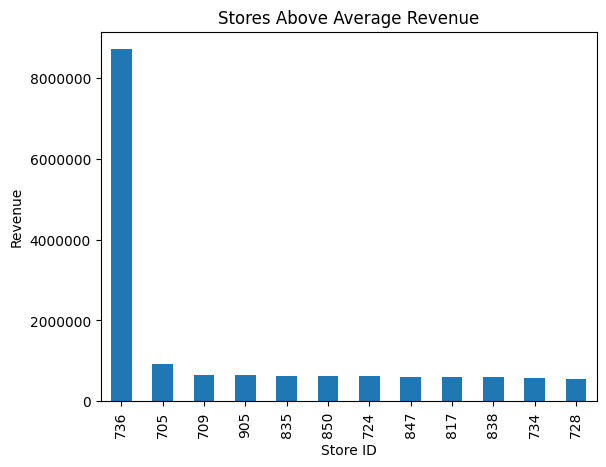

In [43]:
above_avg_revenue.sort_values(ascending=False).plot(
    kind='bar'
)
plt.title('Stores Above Average Revenue')
plt.xlabel('Store ID')
plt.ylabel('Revenue')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

The chart above shows stores with above avarage revenue. Store 736 generates significantly more revenue than the other stores. The remaining stores are still above average but have relatively similar revenue amounts.